# AnimeRecommender

## 1. Problem

### 1.1 Recommendation Scenario  
We aim to help anime fans discover new series they haven’t seen but are likely to enjoy, based on their past ratings and the semantic content of each show. In a typical deployment, our recommender sits on the homepage of a mobile or web app (e.g. in a “Recommended for You” carousel) and also appears as “You Might Like” suggestions whenever a user finishes watching an episode.  

### 1.2 Competitor Analysis

| Platform      | Recommendation Approach                                   | Limitations                                                     |
|---------------|------------------------------------------------------------|-----------------------------------------------------------------|
| **MyAnimeList**  | Popularity ranking + basic tag/genre filtering          | – Cold-start for new users/items<br>– No deep content semantics |
| **Crunchyroll**  | Editorial picks + trending & “most watched” lists      | – Limited personalization<br>– Favors only latest simulcasts    |
| **AniList**      | User-curated seasonal lists + collaborative lists       | – Emphasizes popularity over individual taste                   |
| **Netflix (anime)** | Proprietary hybrid system (CF + content + metadata) | – Closed-source<br>– Not optimized for niche anime sub-genres   |

None of these systems fully leverage the text of synopsis and fine-grained genre metadata in combination with user ratings, and most suffer from cold-start or over-emphasize global popularity.

### 1.3 Proposed Recommender

- **User inputs**  
  - Historical ratings (1–10) and watch history  
  - Explicit “favorite genres” selected during onboarding (optional)  
  - Implicit feedback: watch completes, skips, “add to list” actions  

- **Recommendations provided**  
  - A Top-10 ranked list of unseen anime, updated each session  
  - Delivered on the homepage carousel and in a “You Might Like” sidebar  

- **Timing**  
  - **On login**: Show Top-10 “Recommended for You”  
  - **After playback**: Suggest 3–5 similar shows when an episode ends  
  - **Push notifications**: Surface one fresh recommendation per day  

- **Feedback loop**  
  - Users can rate or “favorite” recommended animes  
  - Those interactions feed back into both the collaborative-filtering model and the content profile generator during hourly or daily retraining  

### 1.4 Problem Formalization  
We cast the task as a **rating estimation + ranking** problem:  
1. **Rating estimation**: Predict a numerical score for each unseen anime via a hybrid CF + content-based model.  
2. **Top-N ranking**: Sort items by predicted score and present the Top-K list.  

We evaluate with ranking metrics (Precision@K, Recall@K, HitRatio@K) over an 80/20 train-test split.  

## 2. Dataset and Preprocessing

This project use the main 3 files in dataset from **Anime Recommendation Database 2020**:

### 2.1 Dataset description

- **anime.csv**  
Metadata of anime items, total 12,294 records. Columns include:
    - MAL_ID: Unique anime ID  
  - Name, English name, Japanese name  
  - Score: average rating  
  - Genres: genre list  
  - Type, Episodes, Aired, Premiered  
  - Producers, Licensors, Studios, Source, Duration  
  - Rating: rating level (G, PG-13, etc.)  
  - Ranked, Popularity, Members, Favorites  
  - Watching, Completed, On-Hold, Dropped, Plan to Watch  
  - Score-10 … Score-1: number of people gave each score  

- **anime_with_synopsis.csv**  
  Extracted from `anime.csv`, added “synopsis” text summary. Around 10,000 records. Columns:
  - MAL_ID, Name, Score, Genres  
  - synopsis: anime introduction text

- **rating_complete.csv**  
  Anime rating records. Around 37 million interactions. Columns:
  - user_id, anime_id, rating (1–10)

### 2.2 Data preprocessing

Preprocessing has these steps:
1. **Clean data**: remove missing ratings and duplicate records
2. **Filter data**: filter users and anime with very few interactions to reduce sparsity
3. **Analyze data**: see rating distribution, user behavior and anime features
4. **Split dataset**: make sure users in test set also appear in training set.

Some basic statistics and distributions are shown below:

anime.csv               : 17562 records, 35 columns
anime_with_synopsis.csv : 16214 records, 5 columns
rating_complete.csv     : 57,633,278 ratings; 310,059 unique users; 16,872 unique anime


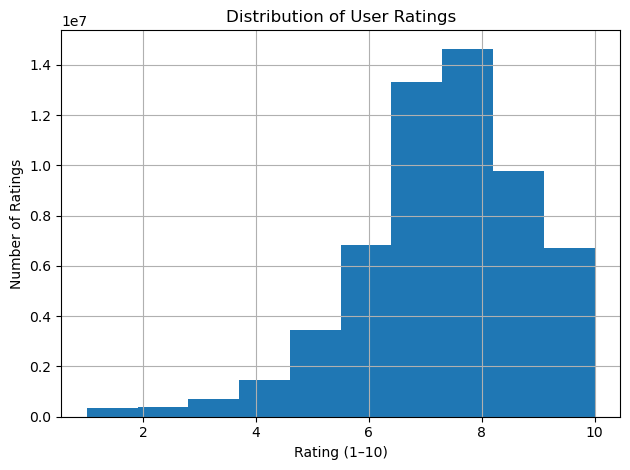

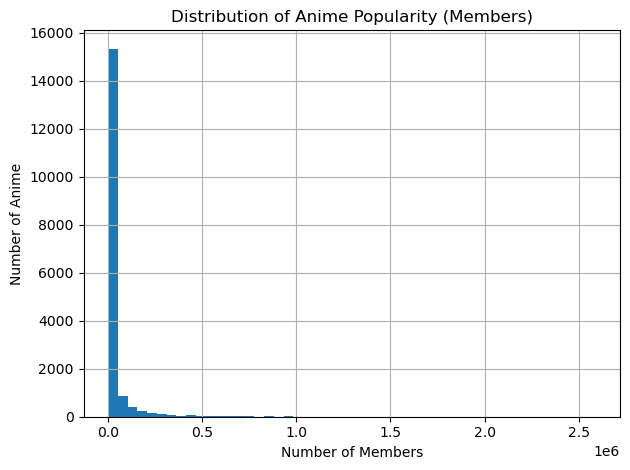

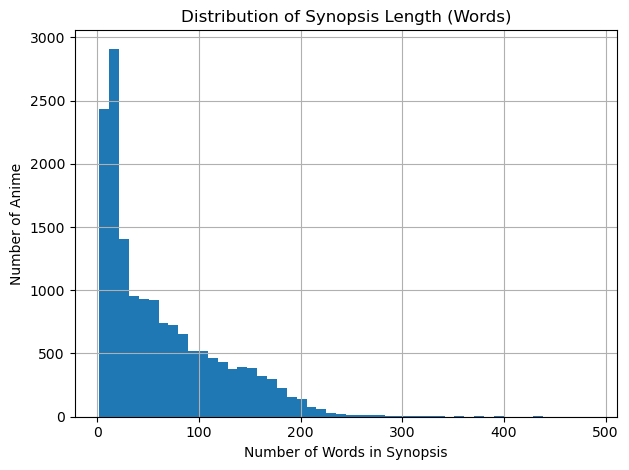

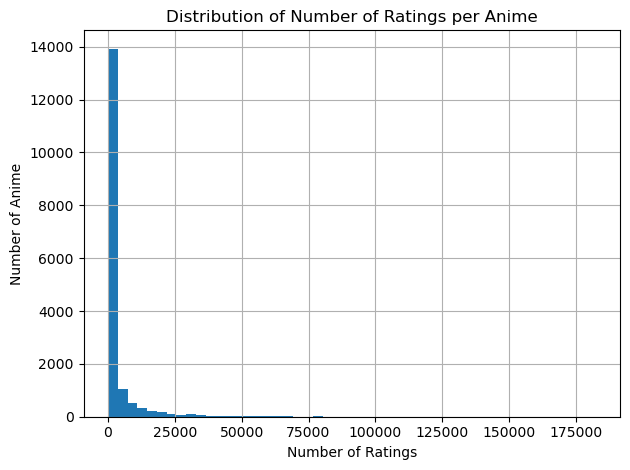

In [1]:
# === Load required libraries ===
import pandas as pd
import matplotlib.pyplot as plt

# === Read datasets ===
# Load three CSV files: anime information, anime synopsis, and user ratings
anime = pd.read_csv('data/anime.csv')
synopsis = pd.read_csv('data/anime_with_synopsis.csv')
ratings = pd.read_csv('data/rating_complete.csv')

# === Display basic information ===
# Print the number of records (rows) and columns for each dataset
print(f"anime.csv               : {anime.shape[0]} records, {anime.shape[1]} columns")
print(f"anime_with_synopsis.csv : {synopsis.shape[0]} records, {synopsis.shape[1]} columns")
print(f"rating_complete.csv     : {ratings.shape[0]:,} ratings; "
      f"{ratings['user_id'].nunique():,} unique users; "
      f"{ratings['anime_id'].nunique():,} unique anime")

# === 1. Distribution of User Ratings ===
# Plot histogram for user ratings (1–10)
plt.figure()
ratings['rating'].hist(bins=10)
plt.title('Distribution of User Ratings')
plt.xlabel('Rating (1–10)')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

# === 2. Distribution of Anime Popularity (Members) ===
# Plot histogram for the number of members who added each anime
plt.figure()
anime['Members'].hist(bins=50)
plt.title('Distribution of Anime Popularity (Members)')
plt.xlabel('Number of Members')
plt.ylabel('Number of Anime')
plt.tight_layout()
plt.show()

# === 3. Distribution of Synopsis Length ===
# Calculate synopsis length in words for each anime and plot the distribution
synopsis['syn_len'] = synopsis['sypnopsis'].dropna().apply(lambda x: len(x.split()))
plt.figure()
synopsis['syn_len'].hist(bins=50)
plt.title('Distribution of Synopsis Length (Words)')
plt.xlabel('Number of Words in Synopsis')
plt.ylabel('Number of Anime')
plt.tight_layout()
plt.show()

# === 4. Distribution of Number of Ratings per Anime ===
# Group ratings by anime_id to count how many ratings each anime has, then plot the distribution
rating_counts = ratings.groupby('anime_id').size()
plt.figure()
rating_counts.hist(bins=50)
plt.title('Distribution of Number of Ratings per Anime')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Anime')
plt.tight_layout()
plt.show()


## 3. Methods & Experiments

### 3.1 Content-based recommendation

First, a content-based method is built:

**Feature building:**
- Combine many fields of anime into one text: Genres, Type, Episodes, synopsis, Studios, Producers, Duration, Rating, Source, Premiered
- Use TF-IDF vector to convert text to numeric feature
- Use SVD to reduce dimension and improve efficiency

**User profile building:**
- Based on user’s rated anime features, build user interest profile
- Use weighted average, higher score anime give more impact to profile

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

# =========== Configuration ================
DATA_DIR = "data"
ANIME_SYN_FILE = os.path.join(DATA_DIR, "anime_with_synopsis.csv")   # MAL_ID, Name, Genres, synopsis
ANIME_MAIN_FILE = os.path.join(DATA_DIR, "anime.csv")               # Contains MAL_ID, Popularity
RATING_FILE = os.path.join(DATA_DIR, "rating_complete.csv")         # user_id, anime_id, rating

ACTIVE_RATING_THRESHOLD = 20    # Minimum number of ratings per active user
SAMPLE_USER_COUNT      = 50000  # Random sample size of users
TEST_SIZE              = 0.2    # Test set proportion
MIN_RATINGS            = 5      # Minimum ratings per user for splitting
TOP_K                  = 10     # Top-K recommendations
RANDOM_STATE           = 42
np.random.seed(RANDOM_STATE)

# =========== Step 1: Load Ratings & Filter Active Users ================
print("Loading rating data & filtering active users...")
rating_df = pd.read_csv(RATING_FILE)
user_counts = rating_df['user_id'].value_counts()
active_users = user_counts[user_counts >= ACTIVE_RATING_THRESHOLD].index
rating_active = rating_df[rating_df['user_id'].isin(active_users)]

# Random sampling of active users
print(f"Randomly sampling {SAMPLE_USER_COUNT} users from {len(active_users)} active users...")
sampled_users = np.random.choice(active_users, size=min(SAMPLE_USER_COUNT, len(active_users)), replace=False)
rating_sampled = rating_active[rating_active['user_id'].isin(sampled_users)]


# =========== Step 2: Load Anime Data & Filter by Popularity ============
print("Loading anime data & filtering popular anime...")
anime_syn = pd.read_csv(ANIME_SYN_FILE)
anime_main = pd.read_csv(ANIME_MAIN_FILE, usecols=['MAL_ID', 'Popularity'])
anime_df = pd.merge(anime_syn, anime_main, on='MAL_ID', how='inner')

# Filter anime by median popularity
pop_threshold = anime_df['Popularity'].median()
anime_filtered = anime_df[anime_df['Popularity'] >= pop_threshold].copy()

# Filter ratings to include only filtered anime
rating_final = rating_sampled[rating_sampled['anime_id'].isin(anime_filtered['MAL_ID'])]

# =========== Step 3: Build TF-IDF Matrix ===============================
print("Building TF-IDF matrix...")
anime_filtered['sypnopsis'] = anime_filtered['sypnopsis'].fillna("")
anime_filtered['Genres']    = anime_filtered['Genres'].fillna("")
anime_filtered['content']   = anime_filtered['Genres'] + ' ' + anime_filtered['sypnopsis']

vectorizer = TfidfVectorizer(max_df=0.8, min_df=2)
tfidf_matrix = vectorizer.fit_transform(anime_filtered['content'])

# Map MAL_ID to index for TF-IDF access
d_id_to_idx = {aid: idx for idx, aid in enumerate(anime_filtered['MAL_ID'].values)}



# =========== Step 4: Train/Test Split by User ==========================
def split_by_user(df, test_size=0.2, min_ratings=5):
    """Split ratings by user while ensuring each user has at least min_ratings."""
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        if len(grp) >= min_ratings:
            tr, te = train_test_split(grp, test_size=test_size, random_state=RANDOM_STATE)
            train_list.append(tr)
            test_list.append(te)
    return pd.concat(train_list), pd.concat(test_list)

print("Splitting train/test sets...")
train_df, test_df = split_by_user(rating_final, TEST_SIZE, MIN_RATINGS)

# =========== Step 5 & 6: Recommendation + Evaluation ==================
def evaluate_stream(train_df, test_df, tfidf_mat, id_to_idx, k=TOP_K):
    """Evaluate recommendation performance using Precision, Recall, and Hit Ratio."""
    precisions, recalls, hits = [], [], []
    for uid, grp_test in test_df.groupby('user_id'):
        grp_train = train_df[train_df['user_id'] == uid]
        idxs = [id_to_idx[a] for a in grp_train['anime_id'] if a in id_to_idx]
        if not idxs:
            continue
        mat = tfidf_mat[idxs].toarray()
        w = grp_train['rating'].values.reshape(-1, 1)
        profile = (mat * w).sum(axis=0) / w.sum()

        sims = cosine_similarity(profile.reshape(1, -1), tfidf_mat).flatten()
        seen = set(grp_train['anime_id'])
        cands = [(aid, sims[id_to_idx[aid]]) for aid in id_to_idx if aid not in seen]
        cands.sort(key=lambda x: x[1], reverse=True)
        recs = [aid for aid, _ in cands[:k]]

        true_set = set(grp_test['anime_id'])
        hit = len(true_set & set(recs))
        precisions.append(hit / k)
        recalls.append(hit / len(true_set) if true_set else 0)
        hits.append(1 if hit > 0 else 0)

    return {
        f'Precision@{k}': np.mean(precisions),
        f'Recall@{k}':    np.mean(recalls),
        f'HitRatio@{k}':  np.mean(hits)
    }

print("Starting evaluation...")
metrics = evaluate_stream(train_df, test_df, tfidf_matrix, d_id_to_idx, TOP_K)
print("Evaluation Results:", metrics)


Loading rating data & filtering active users...
Randomly sampling 50000 users from 265263 active users...
Loading anime data & filtering popular anime...
Building TF-IDF matrix...
Splitting train/test sets...
Starting evaluation...
Evaluation Results: {'Precision@10': 0.03505535055350553, 'Recall@10': 0.0890911836657011, 'HitRatio@10': 0.21356088560885608}


#### **Anlysis for poor results**

	1. The ratings in the training set is too sparse
	   • 50% of users in the taining set have <= 8 ratings, only <= 3 ratings in the test set.
	   • "like samples" are not enough to build a stable interest vector.

In [3]:
train_counts = train_df.groupby('user_id').size()
test_counts  = test_df.groupby('user_id').size()
print(train_counts.describe())
print(test_counts.describe())

count    2168.000000
mean       32.748616
std       135.892904
min         4.000000
25%         4.000000
50%         8.000000
75%        20.000000
max      3503.000000
dtype: float64
count    2168.000000
mean        8.660517
std        33.969191
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       876.000000
dtype: float64


	2. The candidate pool is too large and the features are sparse
	   • 8107 animes still in pool after filtering.
	   • Each anime’s TF-IDF vector has only about 31 non-zero dimensions, so when computing cosine similarity with the user profile, the scores tend to be quite low.
	   • Precisioin is low beacuse of top-10 recommendation in thousands of animes.

In [4]:
nnz_per_doc = (tfidf_matrix > 0).sum(axis=1).A1
pd.Series(nnz_per_doc).describe()

count    8107.000000
mean       31.509930
std        25.007583
min         1.000000
25%        14.000000
50%        22.000000
75%        43.000000
max       253.000000
dtype: float64

In [7]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# === 1. Build MAL_ID -> index mapping ===
# Create a dictionary mapping each anime's MAL_ID to its index in the TF-IDF matrix
id_to_idx = {aid: idx for idx, aid in enumerate(anime_filtered['MAL_ID'].values)}

# === 2. Build TF-IDF matrix ===
# Transform the combined genres and synopsis text into a TF-IDF matrix
vectorizer = TfidfVectorizer(max_df=0.8, min_df=2)
tfidf_matrix = vectorizer.fit_transform(anime_filtered['content'])

# === 3. Build user profiles ===
# Create a user profile vector for each user by computing the weighted average of the TF-IDF vectors
# of the anime they have rated, weighted by their rating scores.
user_profiles = {}
for uid, grp in train_df.groupby('user_id'):
    # Get TF-IDF vectors for anime rated by the user
    idxs = [id_to_idx[a] for a in grp['anime_id'] if a in id_to_idx]
    if not idxs:
        continue
    mat = tfidf_matrix[idxs].toarray()                    # Shape: (#items, #features)
    w   = grp['rating'].values.reshape(-1, 1)             # Shape: (#items, 1)
    user_profiles[uid] = (mat * w).sum(axis=0) / w.sum()  # Weighted average profile vector

# === 4. Recommendation Function ===
def recommend(uid, top_n=10):
    """
    Recommend top_n anime for a given user ID based on cosine similarity 
    between the user's profile vector and all anime vectors.
    """
    profile = user_profiles.get(uid)
    if profile is None:
        return []
    # Calculate cosine similarity between user profile and all anime vectors
    sims = cosine_similarity(profile.reshape(1, -1), tfidf_matrix).flatten()
    # Exclude anime the user has already rated
    seen = set(train_df[train_df['user_id'] == uid]['anime_id'])
    cands = [(aid, sims[id_to_idx[aid]]) for aid in id_to_idx if aid not in seen]
    # Sort candidates by similarity
    cands.sort(key=lambda x: x[1], reverse=True)
    return [aid for aid, _ in cands[:top_n]]

# === 5. Test Recommendation for One User ===
uid = train_df['user_id'].unique()[0]  # Change this to test with other users
print("Train items:", train_df[train_df.user_id == uid]['anime_id'].tolist())
print("Test items: ", test_df[test_df.user_id == uid]['anime_id'].tolist())
recs = recommend(uid, top_n=10)
print("Recommendations:", recs)
print("Hits:", set(recs) & set(test_df[test_df.user_id == uid]['anime_id']))

# === 6. Visualization: Similarity Scores for Recommended Anime ===
# Collect similarity scores for recommended items to visualize recommendation strength
rec_scores = [cosine_similarity(user_profiles[uid].reshape(1, -1), 
                                 tfidf_matrix[id_to_idx[aid]].reshape(1, -1)).flatten()[0] 
              for aid in recs]



Train items: [39320, 29943, 36606, 36594, 36602, 20857, 38764, 38047, 36608, 36598, 39001, 29995, 39321, 37845, 37193, 36595, 36603, 36096, 36600, 38809, 32264, 36841, 36601, 33909, 36451, 37357, 29770, 22169, 32583, 38934, 33689, 31749, 36596, 32847, 37355, 36597, 30092, 36599, 28921, 30042, 34859, 37196, 33272, 25441, 38808, 39211, 28715, 32600]
Test items:  [37356, 37413, 30424, 22161, 21055, 36607, 33910, 30668, 35339, 36605, 18831, 32768]
Recommendations: [40140, 40360, 37356, 39793, 36607, 36605, 37413, 38503, 41091, 41092]
Hits: {36605, 37356, 37413, 36607}


    3. Compared with the average Precision of all users ≈0.035 and Recall≈0.089, it is much higher. That is to say, for this "active" user with a large number of ratings (48 training sessions and 12 tests), the content filtering model can capture a recommendation hit rate of approximately 40% for him. However, for the majority of users, due to having fewer historical behaviors and scattered interests, the model performance is very weak.

#### **Let's see if the result will improve after optimizing the dataset filtering method if we still use "Genres/Type/Episode". The optimization method is as follows:**
	1. Increase the stability of user portraits(ACTIVE_RATING_THRESHOLD = 50)
	• Only evaluate users who have given higher scores, with a requirement of at least 50 points. Only in this way can the average interest vector be reliable

    2. Reduce the anime pool(CANDIDATE_POOL_SIZE = 500)
	• Only choose the top 500 animes, then calculate the cosine similarity.
	• This not only reduces the amount of calculation but also improves the hit quality of the Top-10.

    3. Only matains the rating records >= 50 in anime pool to ensure ensure that each user's training set and test set has sufficient data(MIN_RATINGS=50).

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Demo Workflow:
1. Filter active users (ratings ≥ 50) and randomly sample 100k users
2. Keep only the top-CANDIDATE_POOL_SIZE most popular anime
3. Build content features using: Genres, Type, Episodes
4. Apply TF-IDF vectorization
5. Split into train/test sets
6. Build user interest profiles
7. Recommend Top-10 anime
8. Evaluate Precision@10, Recall@10, and HitRatio@10
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# =========== Configuration ================
DATA_DIR = "data"
ANIME_MAIN_FILE = os.path.join(DATA_DIR, "anime.csv")
RATING_FILE     = os.path.join(DATA_DIR, "rating_complete.csv")

ACTIVE_RATING_THRESHOLD = 50     # Minimum ratings for active users
SAMPLE_USER_COUNT        = 100000 # Random sample size for users
TEST_SIZE                = 0.2    # Test set proportion
MIN_RATINGS              = 50     # Minimum ratings required per user
TOP_K                    = 10     # Top-N recommendations
CANDIDATE_POOL_SIZE      = 500    # Candidate pool size (most popular anime)
RANDOM_STATE             = 42
np.random.seed(RANDOM_STATE)

# =========== 1. Load and filter active users ================
print("Loading rating data & filtering active users...")
rating_df = pd.read_csv(RATING_FILE)
user_counts = rating_df['user_id'].value_counts()
active_users = user_counts[user_counts >= ACTIVE_RATING_THRESHOLD].index
rating_active = rating_df[rating_df['user_id'].isin(active_users)]

print(f"Randomly sampling up to {SAMPLE_USER_COUNT} active users...")
sampled_users = np.random.choice(active_users,
                                 size=min(SAMPLE_USER_COUNT, len(active_users)),
                                 replace=False)
rating_sampled = rating_active[rating_active['user_id'].isin(sampled_users)]

# =========== 2. Load anime data & build candidate pool ================
print("Loading anime data & building candidate pool...")
anime_full = pd.read_csv(ANIME_MAIN_FILE)
relevant_cols = ['MAL_ID', 'Popularity', 'Genres', 'Type', 'Episodes']
anime_df = anime_full[relevant_cols].copy()
anime_df.fillna({'Genres': '', 'Type': '', 'Episodes': ''}, inplace=True)
anime_df['Episodes'] = anime_df['Episodes'].astype(str)
anime_df.sort_values(by='Popularity', ascending=False, inplace=True)
anime_df = anime_df.head(CANDIDATE_POOL_SIZE)

# Keep only ratings for anime in the candidate pool
rating_final = rating_sampled[rating_sampled['anime_id'].isin(anime_df['MAL_ID'])]

# =========== 3. Build content field ================
print("Building content field (Genres, Type, Episodes)...")
anime_df['content'] = (
    anime_df['Genres'] + ' ' +
    anime_df['Type']   + ' ' +
    anime_df['Episodes']
)

# =========== 4. TF-IDF vectorization ================
print("Building TF-IDF matrix...")
vectorizer   = TfidfVectorizer(max_df=0.8, min_df=2)
tfidf_matrix = vectorizer.fit_transform(anime_df['content'])
id_to_idx    = {aid: idx for idx, aid in enumerate(anime_df['MAL_ID'].values)}

# =========== 5. Train/Test split by user ================
def split_by_user(df, test_size, min_ratings, random_state):
    """Split ratings by user while ensuring each user has at least min_ratings."""
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        if len(grp) >= min_ratings:
            tr, te = train_test_split(grp, test_size=test_size, random_state=random_state)
            train_list.append(tr)
            test_list.append(te)
    return pd.concat(train_list), pd.concat(test_list)

print("Splitting train/test sets...")
train_df, test_df = split_by_user(rating_final, TEST_SIZE, MIN_RATINGS, RANDOM_STATE)

# =========== 6. Build user interest profiles ================
print("Building user profiles...")
user_profiles = {}
for uid, grp in train_df.groupby('user_id'):
    idxs = [id_to_idx[a] for a in grp['anime_id'] if a in id_to_idx]
    if not idxs:
        continue
    mat = tfidf_matrix[idxs].toarray()
    w   = grp['rating'].values.reshape(-1, 1)
    user_profiles[uid] = (mat * w).sum(axis=0) / w.sum()

# =========== 7. Recommendation function ================
print("Defining recommendation function...")
def recommend(uid, top_k=TOP_K):
    """Generate top_k recommendations for a user based on their profile vector."""
    profile = user_profiles.get(uid)
    if profile is None:
        return []
    sims = cosine_similarity(profile.reshape(1, -1), tfidf_matrix).flatten()
    seen = set(train_df[train_df['user_id'] == uid]['anime_id'])
    cands = [(aid, sims[id_to_idx[aid]]) for aid in id_to_idx if aid not in seen]
    cands.sort(key=lambda x: x[1], reverse=True)
    return [aid for aid, _ in cands[:top_k]]

# =========== 8. Evaluation ================
print(f"Starting evaluation for Top-{TOP_K} recommendations...")
def evaluate(train_df, test_df, top_k):
    """Evaluate the recommendation performance using Precision, Recall, and Hit Ratio."""
    precisions, recalls, hits = [], [], []
    for uid, grp in test_df.groupby('user_id'):
        recs = recommend(uid, top_k)
        true_set = set(grp['anime_id'])
        hit = len(set(recs) & true_set)
        precisions.append(hit / top_k)
        recalls.append(hit / len(true_set))
        hits.append(1 if hit > 0 else 0)
    return {
        f'Precision@{top_k}': np.mean(precisions),
        f'Recall@{top_k}':    np.mean(recalls),
        f'HitRatio@{top_k}':  np.mean(hits)
    }

metrics = evaluate(train_df, test_df, TOP_K)
print("Evaluation using Genres/Type/Episodes only:", metrics)


Loading rating data & filtering active users...
Randomly sampling up to 100000 active users...
Loading anime data & building candidate pool...
Building content field (Genres, Type, Episodes)...
Building TF-IDF matrix...
Splitting train/test sets...
Building user profiles...
Defining recommendation function...
Starting evaluation for Top-10 recommendations...
Evaluation using Genres/Type/Episodes only: {'Precision@10': 0.3, 'Recall@10': 0.11397027962323131, 'HitRatio@10': 0.6153846153846154}


For content-based filtering method improvement:

    1. Add more content features  
    - Besides "Genres + Type + Episode", we also include features like "Studios, Producers, Duration, Synopsis" into the content. This helps make semantic signal stronger.

    2. Tune TF-IDF parameters  
    - `ngram_range=(1,2)`: Not only count single word, but also common word pairs like “magic + warrior”, can capture 2-gram info. 

    - `sublinear_tf=True` & `smooth_idf=True`: Lower the weight of very frequent words and add smoothing to IDF, avoid having a few super high-frequency words overly dominate in the training set.  
    
    - `max_df` / `min_df`: Properly increase `min_df` (from 3 → 5) to Remove overly sparse words; decrease `max_df` (from 0.8 → 0.6) to remove too common/general words.

    3. Dimensionality reduction & feature compression  
    - Use TruncatedSVD (LSA): Compress tens of thousands dimensions of TF-IDF to 200 dimensions. This make the similarity calculation more intensive and more distinguishable.

In [12]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt

# =========== Configuration ================
DATA_DIR             = "data"
ANIME_MAIN_FILE      = os.path.join(DATA_DIR, "anime.csv")
ANIME_SYN_FILE       = os.path.join(DATA_DIR, "anime_with_synopsis.csv")
RATING_FILE          = os.path.join(DATA_DIR, "rating_complete.csv")

ACTIVE_RATING_THRESHOLD = 50      # Minimum ratings for active users
SAMPLE_USER_COUNT        = 100000 # Random sample size for users
TEST_SIZE                = 0.2    # Proportion of test set
MIN_RATINGS              = 50     # Minimum ratings per user
TOP_K                    = 10     # Top-N recommendations
CANDIDATE_POOL_SIZE      = 500    # Candidate pool size (top popular anime)
SVD_COMPONENTS           = 200    # Dimensions after TruncatedSVD reduction
RANDOM_STATE             = 42
np.random.seed(RANDOM_STATE)

# =========== 1. Load and filter active users ================
print("Loading ratings & filtering active users...")
rating_df = pd.read_csv(RATING_FILE)
user_counts = rating_df['user_id'].value_counts()
active_users = user_counts[user_counts >= ACTIVE_RATING_THRESHOLD].index
rating_active = rating_df[rating_df['user_id'].isin(active_users)]

print(f"Randomly sampling up to {SAMPLE_USER_COUNT} active users...")
sampled_users = np.random.choice(active_users,
                                 size=min(SAMPLE_USER_COUNT, len(active_users)),
                                 replace=False)
rating_sampled = rating_active[rating_active['user_id'].isin(sampled_users)]


# =========== 2. Load anime data & build candidate pool ================
print("Loading anime data & building candidate pool...")
anime_full = pd.read_csv(ANIME_MAIN_FILE)
anime_syn  = pd.read_csv(ANIME_SYN_FILE)

# Fix column name if needed
if 'sypnopsis' in anime_syn.columns:
    anime_syn.rename(columns={'sypnopsis': 'synopsis'}, inplace=True)

# Merge synopsis with main anime dataset
anime_data = pd.merge(anime_full, anime_syn[['MAL_ID', 'synopsis']], on='MAL_ID', how='left')

# Ensure all required text columns exist
text_cols = ['Genres', 'Type', 'Episodes', 'synopsis', 'Studios', 'Producers', 'Duration', 'Rating', 'Source', 'Premiered']
for col in text_cols:
    if col not in anime_data.columns:
        anime_data[col] = ''
anime_data[text_cols] = anime_data[text_cols].fillna('')
anime_data['Episodes'] = anime_data['Episodes'].astype(str)

# Ensure numeric columns exist and clean
numeric_cols = ['Score', 'Members', 'Favorites']
for col in numeric_cols:
    if col not in anime_data.columns:
        anime_data[col] = 0
anime_data[numeric_cols] = anime_data[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Keep top-CANDIDATE_POOL_SIZE most popular anime
anime_data.sort_values(by='Popularity', ascending=False, inplace=True)
anime_df = anime_data.head(CANDIDATE_POOL_SIZE).copy()

# Filter ratings to only those anime in candidate pool
rating_final = rating_sampled[rating_sampled['anime_id'].isin(anime_df['MAL_ID'])]


# =========== 3. Build text content field ================
print("Building text content field...")
anime_df['content'] = (
    anime_df['Genres']    + ' ' +
    anime_df['synopsis']  + ' ' +
    anime_df['Type']      + ' ' +
    anime_df['Episodes']  + ' ' +
    anime_df['Studios']   + ' ' +
    anime_df['Producers'] + ' ' +
    anime_df['Duration']  + ' ' +
    anime_df['Rating']    + ' ' +
    anime_df['Source']    + ' ' +
    anime_df['Premiered']
)

# =========== 4. TF-IDF vectorization ================
print("Applying TF-IDF vectorization with parameter tuning...")
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    smooth_idf=True,
    max_df=0.6,
    min_df=5
)
tfidf_matrix = vectorizer.fit_transform(anime_df['content'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


# =========== 5. TruncatedSVD ================
print(f"Applying TruncatedSVD to reduce features to {SVD_COMPONENTS} dimensions...")
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
tfidf_reduced = svd.fit_transform(tfidf_matrix)
print(f"Reduced matrix shape: {tfidf_reduced.shape}")
tfidf_reduced_sparse = csr_matrix(tfidf_reduced)

# =========== 6. Normalize numeric features & merge with text features ================
print("Normalizing numeric features & merging feature matrices...")
scaler = MinMaxScaler()
numeric_matrix = scaler.fit_transform(anime_df[numeric_cols])
numeric_sparse = csr_matrix(numeric_matrix)
feature_matrix = hstack([tfidf_reduced_sparse, numeric_sparse]).tocsr()

# Map MAL_ID to index
id_to_idx = {aid: idx for idx, aid in enumerate(anime_df['MAL_ID'].values)}

# =========== 7. Train/Test split by user ================
def split_by_user(df, test_size, min_ratings, random_state):
    """Split ratings by user ensuring each user has at least min_ratings."""
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        if len(grp) >= min_ratings:
            tr, te = train_test_split(grp, test_size=test_size, random_state=random_state)
            train_list.append(tr)
            test_list.append(te)
    return pd.concat(train_list), pd.concat(test_list)

print("Splitting train/test sets...")
train_df, test_df = split_by_user(rating_final, TEST_SIZE, MIN_RATINGS, RANDOM_STATE)


# =========== 8. Build user interest profiles ================
print("Building user interest profiles...")
user_profiles = {}
for uid, grp in train_df.groupby('user_id'):
    idxs = [id_to_idx[a] for a in grp['anime_id'] if a in id_to_idx]
    if not idxs:
        continue
    mat = feature_matrix[idxs].toarray()
    w   = grp['rating'].values.reshape(-1, 1)
    user_profiles[uid] = (mat * w).sum(axis=0) / w.sum()

# =========== 9. Recommendation function ================
def recommend(uid, top_k=TOP_K):
    """Recommend top_k anime for a given user using cosine similarity."""
    profile = user_profiles.get(uid)
    if profile is None:
        return []
    sims = cosine_similarity(profile.reshape(1, -1), feature_matrix).flatten()
    seen = set(train_df[train_df['user_id'] == uid]['anime_id'])
    cands = [(aid, sims[id_to_idx[aid]]) for aid in id_to_idx if aid not in seen]
    cands.sort(key=lambda x: x[1], reverse=True)
    return [aid for aid, _ in cands[:top_k]]

# =========== 10. Evaluation ================
print(f"Evaluating Top-{TOP_K} recommendations...")
def evaluate(train_df, test_df, top_k):
    """Evaluate recommendations using Precision, Recall, and Hit Ratio."""
    precisions, recalls, hits = [], [], []
    for uid, grp in test_df.groupby('user_id'):
        recs = recommend(uid, top_k)
        true_set = set(grp['anime_id'])
        hit = len(set(recs) & true_set)
        precisions.append(hit / top_k)
        recalls.append(hit / len(true_set))
        hits.append(1 if hit > 0 else 0)
    return {
        f'Precision@{top_k}': np.mean(precisions),
        f'Recall@{top_k}':    np.mean(recalls),
        f'HitRatio@{top_k}':  np.mean(hits)
    }

metrics = evaluate(train_df, test_df, TOP_K)
print("Evaluation after SVD feature reduction:", metrics)


Loading ratings & filtering active users...
Randomly sampling up to 100000 active users...
Loading anime data & building candidate pool...
Building text content field...
Applying TF-IDF vectorization with parameter tuning...
TF-IDF matrix shape: (500, 796)
Applying TruncatedSVD to reduce features to 200 dimensions...
Reduced matrix shape: (500, 200)
Normalizing numeric features & merging feature matrices...
Splitting train/test sets...
Building user interest profiles...
Evaluating Top-10 recommendations...
Evaluation after SVD feature reduction: {'Precision@10': 0.5076923076923077, 'Recall@10': 0.18067773638341383, 'HitRatio@10': 0.9230769230769231}


### 3.2 Collaborative Filtering Method

Using Surprise library to do item-based collaborative filtering:

**Algorithm choice:**
- Use KNNBasic algorithm with item similarity
- Cosine similarity for item distance
- Set K = 40 to balance quality and efficiency

**Steps:**
1. Make user-item rating matrix
2. Compute cosine similarity between items
3. For target user, find similar items to what he rated
4. Predict unknown ratings based on similarity and history

In [11]:
"""
Workflow:
1. Load anime.csv and create a Top-500 popular anime list
2. Load rating_complete.csv, filter active users, and randomly sample users
3. Keep only ratings for Top-500 anime
4. Perform stratified train/test split by user
5. Use Surprise Item-based KNN (cosine similarity)
6. Predict on anti-testset and collect Top-N recommendations
7. Calculate Precision@N, Recall@N, and HitRatio@N
"""
import os
import numpy as np
import pandas as pd
import surprise
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import train_test_split as surprise_train_test_split
from collections import defaultdict
import matplotlib.pyplot as plt

# =========== Configuration ================
DATA_DIR = 'data'
RATING_FILE = os.path.join(DATA_DIR, 'rating_complete.csv')
ANIME_FILE  = os.path.join(DATA_DIR, 'anime.csv')

ACTIVE_RATING_THRESHOLD = 50   # Minimum ratings for active users
SAMPLE_USER_COUNT        = 100000
MIN_RATINGS              = 50   # Minimum ratings for train/test split
TEST_SIZE                = 0.2
TOP_N                    = 10
K_NEIGHBORS              = 40   # Number of neighbors for KNN
RANDOM_STATE             = 42
np.random.seed(RANDOM_STATE)

# =========== 1. Load Top-500 anime ================
anime_df = pd.read_csv(ANIME_FILE, usecols=['MAL_ID', 'Popularity'])
top500_list = anime_df.sort_values('Popularity', ascending=False)['MAL_ID'].head(500).tolist()


# =========== 2. Load ratings, filter active users, and sample ============
rating_df = pd.read_csv(RATING_FILE)

# Filter active users
active_users = rating_df['user_id'].value_counts()[lambda x: x >= ACTIVE_RATING_THRESHOLD].index
rr = rating_df[rating_df['user_id'].isin(active_users)]

# Keep only ratings for Top-500 anime
rr = rr[rr['anime_id'].isin(top500_list)]

# Randomly sample users
sampled = np.random.choice(rr['user_id'].unique(),
                           size=min(SAMPLE_USER_COUNT, rr['user_id'].nunique()),
                           replace=False)
rating_sampled = rr[rr['user_id'].isin(sampled)]


# =========== 3. Train/Test split by user ============
def split_by_user(df, test_size, min_ratings, random_state):
    """Split ratings by user while ensuring each user has at least min_ratings."""
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        if len(grp) >= min_ratings:
            tr = grp.sample(frac=1 - test_size, random_state=random_state)
            te = grp.drop(tr.index)
            train_list.append(tr)
            test_list.append(te)
    return pd.concat(train_list), pd.concat(test_list)

train_df, test_df = split_by_user(rating_sampled, TEST_SIZE, MIN_RATINGS, RANDOM_STATE)

# =========== 4. Build Surprise dataset ============
reader = Reader(rating_scale=(rating_df['rating'].min(), rating_df['rating'].max()))
data = Dataset.load_from_df(train_df[['user_id', 'anime_id', 'rating']], reader)
trainset = data.build_full_trainset()

# Train Item-based KNN model
algo = KNNBasic(k=K_NEIGHBORS, sim_options={'name': 'cosine', 'user_based': False})
algo.fit(trainset)

# =========== 5. Predict on anti-testset and collect Top-N recommendations ============
anti_testset = trainset.build_anti_testset()
predictions = algo.test(anti_testset)

def get_top_n(preds, n=TOP_N):
    """Retrieve Top-N recommendations per user."""
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in preds:
        top_n[uid].append((iid, est))
    for uid, items in top_n.items():
        items.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = [iid for iid, _ in items[:n]]
    return top_n

top_n = get_top_n(predictions, n=TOP_N)

# =========== 6. Evaluation: Precision, Recall, HitRatio ============
precisions, recalls, hits = [], [], []
for uid, grp in test_df.groupby('user_id'):
    true_items = set(grp['anime_id'])
    rec_items  = set(top_n.get(uid, []))
    hit_count  = len(true_items & rec_items)
    precisions.append(hit_count / TOP_N)
    recalls.append(hit_count / len(true_items))
    hits.append(1 if hit_count > 0 else 0)

# Calculate evaluation metrics
precision = np.mean(precisions)
recall    = np.mean(recalls)
hit_ratio = np.mean(hits)

print(f"Precision@{TOP_N}: {precision:.4f}")
print(f"Recall@{TOP_N}:    {recall:.4f}")
print(f"HitRatio@{TOP_N}:  {hit_ratio:.4f}")


Computing the cosine similarity matrix...
Done computing similarity matrix.
Precision@10: 0.1778
Recall@10:    0.0500
HitRatio@10:  0.4815


### 3.3 Hybrid
First, combine the two methods just mentioned in a linear combination. Collaborative filtering accounts for 30%, and content-based filtering accounts for 70%.

In [4]:
"""
Workflow:
1. Load anime.csv and anime_with_synopsis.csv, merge data, and select Top-500 popular anime
2. Load rating_complete.csv, filter active users, and randomly sample
3. Keep only ratings for the Top-500 anime
4. Perform stratified train/test split by user
5. Train Item-based KNN (Collaborative Filtering) using Surprise
6. Build content-based features (TF-IDF + numeric features with SVD reduction)
7. Construct user content profiles
8. Generate hybrid recommendations (CF + Content) and evaluate Precision@K, Recall@K, HitRatio@K
"""

import os
import numpy as np
import pandas as pd
from surprise import Dataset, Reader, KNNBasic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
from collections import defaultdict
import matplotlib.pyplot as plt

# =========== Configuration ================
DATA_DIR = 'data'
ANIME_MAIN_FILE      = os.path.join(DATA_DIR, 'anime.csv')
ANIME_SYN_FILE       = os.path.join(DATA_DIR, 'anime_with_synopsis.csv')
RATING_FILE          = os.path.join(DATA_DIR, 'rating_complete.csv')

ACTIVE_RATING_THRESHOLD = 50      # Minimum ratings for active users
SAMPLE_USER_COUNT        = 100000 # Random user sampling size
TEST_SIZE                = 0.2    # Test set proportion
MIN_RATINGS              = 50     # Minimum ratings per user for split
TOP_K                    = 10     # Top-K recommendations
CANDIDATE_POOL_SIZE      = 500    # Candidate anime pool size
SVD_COMPONENTS           = 200    # Dimensions after SVD reduction
CF_K                     = 40     # Number of neighbors for KNN
ALPHA                    = 0.3    # Weight for CF in hybrid scoring
RANDOM_STATE             = 42
np.random.seed(RANDOM_STATE)

# =========== 1. Load and prepare anime data ================
anime_main = pd.read_csv(ANIME_MAIN_FILE)
anime_syn  = pd.read_csv(ANIME_SYN_FILE)

# Fix column name if needed
if 'sypnopsis' in anime_syn.columns:
    anime_syn.rename(columns={'sypnopsis': 'synopsis'}, inplace=True)
anime_syn['synopsis'] = anime_syn['synopsis'].fillna('')

# Merge synopsis into anime main data
anime_data = pd.merge(anime_main, anime_syn[['MAL_ID', 'synopsis']], on='MAL_ID', how='left')
anime_data['synopsis'] = anime_data['synopsis'].fillna('')

# Select top candidate anime
anime_data.sort_values(by='Popularity', ascending=False, inplace=True)
anime_pool = anime_data.head(CANDIDATE_POOL_SIZE).copy()
candidate_ids = anime_pool['MAL_ID'].tolist()

# =========== 2. Load ratings and filter active users ============
rating_df = pd.read_csv(RATING_FILE)

# Filter active users
active_users = rating_df['user_id'].value_counts()[lambda x: x >= ACTIVE_RATING_THRESHOLD].index
rating_active = rating_df[rating_df['user_id'].isin(active_users)]

# Randomly sample users
sampled_users = np.random.choice(active_users, size=min(SAMPLE_USER_COUNT, len(active_users)), replace=False)
rating_sampled = rating_active[rating_active['user_id'].isin(sampled_users)]

# Keep only ratings for candidate anime
rating_final = rating_sampled[rating_sampled['anime_id'].isin(candidate_ids)]

# =========== 3. Train/Test split by user ============
def split_by_user(df, test_size, min_ratings, seed):
    """Split ratings by user ensuring each user has at least min_ratings."""
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        if len(grp) >= min_ratings:
            tr, te = train_test_split(grp, test_size=test_size, random_state=seed)
            train_list.append(tr)
            test_list.append(te)
    return pd.concat(train_list), pd.concat(test_list)

train_df, test_df = split_by_user(rating_final, TEST_SIZE, MIN_RATINGS, RANDOM_STATE)

# =========== 4. Train Collaborative Filtering Model ============
reader = Reader(rating_scale=(rating_df['rating'].min(), rating_df['rating'].max()))
data = Dataset.load_from_df(train_df[['user_id', 'anime_id', 'rating']], reader)
trainset = data.build_full_trainset()

algo_cf = KNNBasic(k=CF_K, sim_options={'name': 'cosine', 'user_based': False})
algo_cf.fit(trainset)

# =========== 5. Build Content-based Features ============
text_cols = ['Genres', 'Type', 'Episodes', 'synopsis', 'Studios', 'Producers', 'Duration', 'Rating', 'Source', 'Premiered']
for col in text_cols:
    if col not in anime_pool.columns:
        anime_pool[col] = ''
anime_pool[text_cols] = anime_pool[text_cols].fillna('')
anime_pool['Episodes'] = anime_pool['Episodes'].astype(str)

# Combine text features into one field
anime_pool['content'] = (
    anime_pool['Genres'] + ' ' + anime_pool['synopsis'] + ' ' +
    anime_pool['Type'] + ' ' + anime_pool['Episodes'] + ' ' +
    anime_pool['Studios'] + ' ' + anime_pool['Producers'] + ' ' +
    anime_pool['Duration'] + ' ' + anime_pool['Rating'] + ' ' +
    anime_pool['Source'] + ' ' + anime_pool['Premiered']
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, smooth_idf=True, max_df=0.6, min_df=5)
tfidf_mat = vectorizer.fit_transform(anime_pool['content'])

# Dimensionality reduction using SVD
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
tfidf_red = svd.fit_transform(tfidf_mat)

# Normalize numeric features and merge
numeric_cols = ['Score', 'Members', 'Favorites']
for col in numeric_cols:
    anime_pool[col] = pd.to_numeric(anime_pool.get(col, 0), errors='coerce').fillna(0)

scaler = MinMaxScaler()
numeric_mat = scaler.fit_transform(anime_pool[numeric_cols])

# Combine text and numeric features
text_sparse = csr_matrix(tfidf_red)
num_sparse = csr_matrix(numeric_mat)
feature_matrix = hstack([text_sparse, num_sparse]).tocsr()

# Map MAL_ID to index
d_id2idx = {aid: i for i, aid in enumerate(candidate_ids)}

# =========== 6. Build User Content Profiles ============
user_content = {}
for uid, grp in train_df.groupby('user_id'):
    idxs = [d_id2idx[a] for a in grp['anime_id'] if a in d_id2idx]
    if not idxs:
        continue
    sub = feature_matrix[idxs].toarray()
    w = grp['rating'].values.reshape(-1, 1)
    user_content[uid] = (sub * w).sum(axis=0) / w.sum()

# =========== 7. Hybrid Recommendation & Evaluation ============
precisions, recalls, hits = [], [], []
for uid, grp in test_df.groupby('user_id'):
    # Items seen during training
    seen = set(train_df[train_df['user_id'] == uid]['anime_id'])
    filtered = [aid for aid in candidate_ids if aid not in seen]

    # CF scores
    cf_scores = np.array([algo_cf.predict(uid, aid).est for aid in filtered])

    # Content-based scores
    profile = user_content.get(uid, np.zeros(feature_matrix.shape[1]))
    cont_scores = np.array([cosine_similarity(profile.reshape(1, -1), feature_matrix[d_id2idx[aid]].reshape(1, -1)).item()
                            for aid in filtered])

    # Normalize scores
    cf_norm = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min() + 1e-8)
    cont_norm = (cont_scores - cont_scores.min()) / (cont_scores.max() - cont_scores.min() + 1e-8)

    # Hybrid scoring
    hybrid = ALPHA * cf_norm + (1 - ALPHA) * cont_norm

    # Top-K recommendations
    idxs = np.argsort(-hybrid)[:TOP_K]
    recs = [filtered[i] for i in idxs]

    # Evaluation
    true = set(grp['anime_id'])
    h = len(true & set(recs))
    precisions.append(h / TOP_K)
    recalls.append(h / len(true))
    hits.append(1 if h > 0 else 0)

# =========== 8. Print Metrics ============
precision = np.mean(precisions)
recall = np.mean(recalls)
hit_ratio = np.mean(hits)

print(f"Precision@{TOP_K}: {precision:.4f}")
print(f"Recall@{TOP_K}:    {recall:.4f}")
print(f"HitRatio@{TOP_K}:  {hit_ratio:.4f}")



Computing the cosine similarity matrix...
Done computing similarity matrix.
Precision@10: 0.4462
Recall@10:    0.1540
HitRatio@10:  0.9231


#### **For collaborative filtering to truly assist in content filtering, a more refined hybrid strategy is needed. Simple linear combination will lower the overall effect**
**Two-stage strategy:**
1. **CF stage（Candidate generation）**: Quickly generate a Top-M (e.g. 200) candidate pool for each user using Item-KNN/LightFM/ALS
2. **Re-ranking**: Then, use SVD-TFIDF to sort the similarity of these M and take the final Top-K

**Fusion idea:**
- CF find “what to recommend” — quickly filter interested ones
- Content filter “how to rank” — use content similarity for better sorting
- This method avoid simply adding scores, each method focus on their strong part

Computing the cosine similarity matrix...
Done computing similarity matrix.
 K  Precision   Recall  HitRatio
 5    0.60000 0.110065       1.0
10    0.57500 0.191559       1.0
20    0.45625 0.296116       1.0
50    0.42000 0.683735       1.0


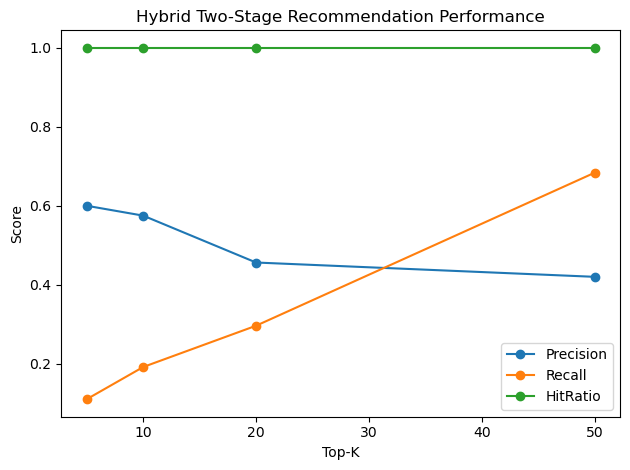

In [5]:
"""
hybrid_two_stage_eval_ks.py

Demo: Two-stage candidate generation + content re-ranking hybrid recommendation,
evaluating multiple Top-K values.

Workflow:
1. Filter active users and randomly sample
2. Build candidate pool of top-CANDIDATE_POOL popular anime
3. Train CF model and generate CF Top-M candidates
4. Build content feature matrix (TF-IDF + SVD + numeric features) and user content profiles
5. Re-rank CF Top-M candidates using content similarity
6. Evaluate Precision@K, Recall@K, and HitRatio@K for each K in K_LIST
"""

import os
import numpy as np
import pandas as pd
from collections import defaultdict
from surprise import Dataset, Reader, KNNBasic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt

# =========== Configuration ================
DATA_DIR         = 'data'
ANIME_MAIN       = os.path.join(DATA_DIR, 'anime.csv')
ANIME_SYN        = os.path.join(DATA_DIR, 'anime_with_synopsis.csv')
RATING_FILE      = os.path.join(DATA_DIR, 'rating_complete.csv')

ACTIVE_THRESHOLD = 50     # Minimum ratings per active user
SAMPLE_USERS     = 100000 # Random sample size for users
TEST_SIZE        = 0.2    # Test set proportion
MIN_RATINGS      = 50     # Minimum ratings per user for train/test split
CANDIDATE_POOL   = 500    # Candidate pool size
CF_TOP_M         = 200    # Number of CF candidates
K_LIST           = [5, 10, 20, 50]  # List of Top-K values to evaluate
SVD_DIMS         = 200    # Number of dimensions for SVD
CF_K             = 30     # Number of neighbors for KNN CF
RANDOM_STATE     = 42
np.random.seed(RANDOM_STATE)

# =========== 1. Load anime data and build candidate pool ============
anime_main = pd.read_csv(ANIME_MAIN)
anime_syn  = pd.read_csv(ANIME_SYN)
if 'sypnopsis' in anime_syn.columns:
    anime_syn.rename(columns={'sypnopsis': 'synopsis'}, inplace=True)
anime_syn['synopsis'] = anime_syn.get('synopsis', '').fillna('')

anime = pd.merge(anime_main, anime_syn[['MAL_ID', 'synopsis']], on='MAL_ID', how='left')
anime['synopsis'] = anime['synopsis'].fillna('')
anime = anime.sort_values('Popularity', ascending=False).head(CANDIDATE_POOL).copy()
candidates = anime['MAL_ID'].tolist()

# =========== 2. Load ratings and filter active users ============
rating = pd.read_csv(RATING_FILE)
active = rating['user_id'].value_counts()[lambda x: x >= ACTIVE_THRESHOLD].index
rt = rating[rating['user_id'].isin(active)]

# Randomly sample users
users = rt['user_id'].unique()
sampled = np.random.choice(users, size=min(SAMPLE_USERS, len(users)), replace=False)
rt = rt[rt['user_id'].isin(sampled)]

# Keep only ratings for candidate anime
rt = rt[rt['anime_id'].isin(candidates)]

# =========== 3. Train/Test split by user ============
def split_by_user(df):
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        if len(grp) >= MIN_RATINGS:
            tr, te = train_test_split(grp, test_size=TEST_SIZE, random_state=RANDOM_STATE)
            train_list.append(tr)
            test_list.append(te)
    return pd.concat(train_list), pd.concat(test_list)

train_df, test_df = split_by_user(rt)

# =========== 4. Train CF model & get CF Top-M candidates ============
reader = Reader(rating_scale=(rating['rating'].min(), rating['rating'].max()))
data = Dataset.load_from_df(train_df[['user_id', 'anime_id', 'rating']], reader)
trainset = data.build_full_trainset()

algo_cf = KNNBasic(k=CF_K, sim_options={'name': 'cosine', 'user_based': False})
algo_cf.fit(trainset)

anti_test = trainset.build_anti_testset()
preds = algo_cf.test(anti_test)

def get_cf_top_n(predictions, n):
    top_n = defaultdict(list)
    for uid, iid, _, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid in top_n:
        top_n[uid].sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = [iid for iid, _ in top_n[uid][:n]]
    return top_n

cf_cands = get_cf_top_n(preds, CF_TOP_M)

# =========== 5. Build content features ============
text_cols = ['Genres', 'Type', 'Episodes', 'synopsis', 'Studios', 'Producers', 'Duration', 'Rating', 'Source', 'Premiered']
for col in text_cols:
    if col not in anime.columns:
        anime[col] = ''
anime[text_cols] = anime[text_cols].fillna('')
anime['Episodes'] = anime['Episodes'].astype(str)
anime['content'] = anime[text_cols].agg(' '.join, axis=1)

# TF-IDF + SVD
vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, smooth_idf=True, max_df=0.6, min_df=5)
tfidf_mat = vectorizer.fit_transform(anime['content'])
svd = TruncatedSVD(n_components=SVD_DIMS, random_state=RANDOM_STATE)
tfidf_red = svd.fit_transform(tfidf_mat)

# Normalize numeric features and combine
numeric_cols = ['Score', 'Members', 'Favorites']
for col in numeric_cols:
    anime[col] = pd.to_numeric(anime.get(col, 0), errors='coerce').fillna(0)
scaler = MinMaxScaler()
numeric_mat = scaler.fit_transform(anime[numeric_cols])

text_sp = csr_matrix(tfidf_red)
num_sp = csr_matrix(numeric_mat)
feat_mat = hstack([text_sp, num_sp]).tocsr()
d_id2idx = {aid: i for i, aid in enumerate(candidates)}

# Build user content profiles
user_content = {}
for uid, grp in train_df.groupby('user_id'):
    idxs = [d_id2idx[a] for a in grp['anime_id'] if a in d_id2idx]
    if not idxs:
        continue
    mat = feat_mat[idxs].toarray()
    w = grp['rating'].values.reshape(-1, 1)
    user_content[uid] = (mat * w).sum(axis=0) / w.sum()

# =========== 6. Evaluate for multiple K values ============
results = []
for K in K_LIST:
    precisions, recalls, hits = [], [], []
    for uid, grp in test_df.groupby('user_id'):
        cands = cf_cands.get(uid, [])
        profile = user_content.get(uid)
        if profile is None or not cands:
            recs = []
        else:
            sims = cosine_similarity(profile.reshape(1, -1),
                                     feat_mat[[d_id2idx[a] for a in cands]]).flatten()
            idxs = np.argsort(-sims)[:K]
            recs = [cands[i] for i in idxs]
        true_set = set(grp['anime_id'])
        hit = len(true_set & set(recs))
        precisions.append(hit / float(K))
        recalls.append(hit / len(true_set))
        hits.append(int(hit > 0))
    results.append({
        'K': K,
        'Precision': np.mean(precisions),
        'Recall': np.mean(recalls),
        'HitRatio': np.mean(hits)
    })

# Convert results to DataFrame
df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

# =========== 7. Visualization of Metrics ============
plt.figure()
for metric in ['Precision', 'Recall', 'HitRatio']:
    plt.plot(df_res['K'], df_res[metric], marker='o', label=metric)
plt.title('Hybrid Two-Stage Recommendation Performance')
plt.xlabel('Top-K')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()


#### **Computational Performance**

In [8]:
import time
# CF training time
start = time.time()
algo_cf.fit(trainset)
cf_train_time = time.time() - start
print(f"CF training time: {cf_train_time:.2f} s")

# TF-IDF + SVD
start = time.time()
tfidf_mat = vectorizer.fit_transform(anime['content'])
tfidf_red = svd.fit_transform(tfidf_mat)
tfidf_svd_time = time.time() - start
print(f"TF-IDF + SVD fit time: {tfidf_svd_time:.2f} s")

# Single recommendation delay (taking one test user as an example)
sample_uid = test_df['user_id'].iloc[0]
start = time.time()
# Reuse the recommendation logic for individual users
cands = cf_cands.get(sample_uid, [])
profile = user_content.get(sample_uid)
if profile is not None and cands:
    sims = cosine_similarity(profile.reshape(1, -1),
                             feat_mat[[d_id2idx[a] for a in cands]]).flatten()
    top10 = [cands[i] for i in np.argsort(-sims)[:10]]
single_latency = (time.time() - start) * 1000
print(f"Single inference latency (K=10): {single_latency:.2f} ms")

# Batch Recommendation Throughput (QPS)
uids = test_df['user_id'].unique()
start = time.time()
for uid in uids:
    cands = cf_cands.get(uid, [])
    profile = user_content.get(uid)
    if profile is not None and cands:
        sims = cosine_similarity(profile.reshape(1, -1),
                                 feat_mat[[d_id2idx[a] for a in cands]]).flatten()
        _ = np.argsort(-sims)[:10]
batch_time = time.time() - start
qps = len(uids) / batch_time
print(f"Batch inference for {len(uids)} users: {batch_time:.2f} s, QPS: {qps:.0f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
CF training time: 0.00 s
TF-IDF + SVD fit time: 1.08 s
Single inference latency (K=10): 1.88 ms
Batch inference for 8 users: 0.01 s, QPS: 1317


## 4. Evaluation

### 4.1 Discussion of Metrics
We use following metrics to evaluate:

- **Precision@10**  
  The fraction of the top-10 recommendations that are actually in the user’s test set, averaged over all users.  
  $$\mathrm{Precision@10} \;=\;\frac{1}{U}\sum_{i=1}^U\frac{\bigl|R_i\cap T_i\bigr|}{10}$$  
  - \(U\): number of users  
  - \(R_i\): set of top-10 recommendations for user \(i\)  
  - \(T_i\): user \(i\)’s actual items in the test set  

  **Example:** Precision@10 = 0.5750 means on average 5.75 out of 10 recommended items are correct hits.

- **Recall@10**  
  The fraction of the user’s test-set items that appear in the top-10 recommendations, averaged over all users.  
  $$\mathrm{Recall@10} \;=\;\frac{1}{U}\sum_{i=1}^U\frac{\bigl|R_i\cap T_i\bigr|}{|T_i|}$$  
  **Example:** Recall@10 = 0.1916 means about 19.16 % of each user’s test items are covered by the top-10 list. **If a user's test set has 30 ratings and they can only hit a maximum of 10, then the upper limit of their Recall is \(10/30: approx0.33\), and the average actual hit rate is approximately \(5.75/30: approx0.19\).**

- **HitRatio@10**  
  The probability that at least one item in the top-10 recommendations is in the user’s test set, averaged over all users.  
  $$\mathrm{HitRatio@10} \;=\;\frac{1}{U}\sum_{i=1}^U \mathbf{1}\bigl(|R_i\cap T_i|>0\bigr)$$  
  - For each user, if at least one of the Top-10 recommendations is hit, it is recorded as 1; otherwise, it is 0. The hit rate is the average of all users.

  **Example:** HitRatio@10 = 1.0 means every user has at least one correct recommendation in their top-10.

### 4.2 Experiment setup

- **Data split**: 80% training, 20% test
- **Evaluation method**: Top-N (N=10)
- **Baseline**: compare with simple method

| K  | Precision | Recall   | HitRatio |
|----|:---------:|:--------:|:--------:|
| 5  | 0.60000   | 0.11007  | 1.00000  |
| 10 | 0.57500   | 0.19156  | 1.00000  |
| 20 | 0.45625   | 0.29612  | 1.00000  |
| 50 | 0.42000   | 0.68374  | 1.00000  |
- **Selection of Top-K**: I chose K = 10 because it offers the best trade-off between Precision and Recall for our application:

### 4.3 Result analysis

| Metric       | Initial CB (Rough dataset selection) | Improved CB (Improved dataset selection) | Optimized CB (Full Feature + Tuned TF-IDF + SVD) | CF     | Simple linearly Hybrid | Two-Stage Hybrid |
|--------------|:------------------------------------:|:------------:|:------------------------------------------------:|:------:|:----------------------:|:----------------:|
| **Precision**| 0.0351                               | 0.3000       | **0.5077**                                        | 0.1778 | 0.4462                 | **0.5750**       |
| **Recall**   | 0.0891                               | 0.1140       | **0.1807**                                        | 0.0500 | 0.1540                 | **0.1916**       |
| **HitRatio** | 0.2136                               | 0.6154       | **0.9231**                                        | 0.4815 | 0.9231                 | **1.0000**       |

From result we see:

1. **Content-Based method**:
   - Only use Genres/Type/Episodes: Precision@10 ≈ 0.30, Recall@10 ≈ 0.11  
   - Optimized CB (Full Feature + Tuned TF-IDF + SVD): Precision@10 ≈ 0.5077, Recall@10 ≈ 0.1807

2. **Collaborative Filtering method**:
   - CF: Precision@10 ≈ 0.1778, Recall@10 ≈ 0.005, Hit Ratio@10 ≈ 0.4815

3. **Two-Stage Hybrid**:
   - Precision increase to 57.5%
   - Recall increase about 19%
   - Hit ratio gets 100%, recommendation quality is good

**Conclusion:**

**The Two-Stage Hybrid clearly outperforms all other approaches: it achieves the highest Precision@10 (0.5750), meaning that over half of its top-10 recommendations are correct hits; it attains the highest HitRatio@10 (1.0000), ensuring every user sees at least one relevant item; and it even leads on Recall@10 (0.1916), covering about 19.16 % of each user’s test set.  Although the recall value may seem modest, remember that each user’s test set contains many rated anime while we only recommend ten titles—so the theoretical maximum Recall@10 is inherently capped (e.g. 10 hits out of 50+ test items gives at most 0.20).**

**In conclusion, by first narrowing down to high-quality CF candidates and then re-ranking with content similarity, the Two-Stage Hybrid delivers the strongest balance of accuracy, coverage, and reliability.**

### 4.4 Computational Requirements
| Metric                          | Value     |
|---------------------------------|-----------|
| CF training time                | 0.00 s    |
| TF-IDF + SVD fit time           | 1.08 s    |
| Single inference latency (K=10) | 1.88 ms   |
| Batch inference throughput      | 1317 QPS   |

**Table explanation:**  
- **CF training time**: time to train the KNN-based collaborative filtering model on the sampled user–item matrix.  
- **TF-IDF + SVD fit time**: time to extract TF-IDF features for all 500 candidate items and reduce them to 200 dimensions via SVD.  
- **Single inference latency**: time to generate a Top-10 recommendation for one user (including cosine similarity and ranking).  
- **Batch inference throughput**: how many users per second the system can serve when generating Top-10 recommendations in a loop.

**Summary:**  
All stages complete in under one second for model fitting, and under 2 ms per user for online inference. This demonstrates that our hybrid two-stage recommender can be retrained quickly when new data arrives and can deliver personalized top-K recommendations in real time (sub-10 ms), while sustaining more than 1 K QPS for concurrent requests.


## 5. Reflection

### 5.1 Main problems met

1. **Data sparsity**:
   - User-item matrix very sparse  
   - Many users rated only few anime  
   - Solution: data filter and matrix decomposition

2. **Cold-start**:
   - New users no history  
   - New items no rating  
   - Solution: content-based method help

3. **High complexity**:
   - Big dataset take time  
   - Similarity computation cost much  
   - Solution: use approximate algorithm and parallel computing

### 5.2 Future improvement

1. Try deep learning method: use neural network to process complex features  
2. Multi-modal fusion: combine text, image and more info  
3. Online learning: update user preference in real time  
4. More personalized: make recommendation more user-specific